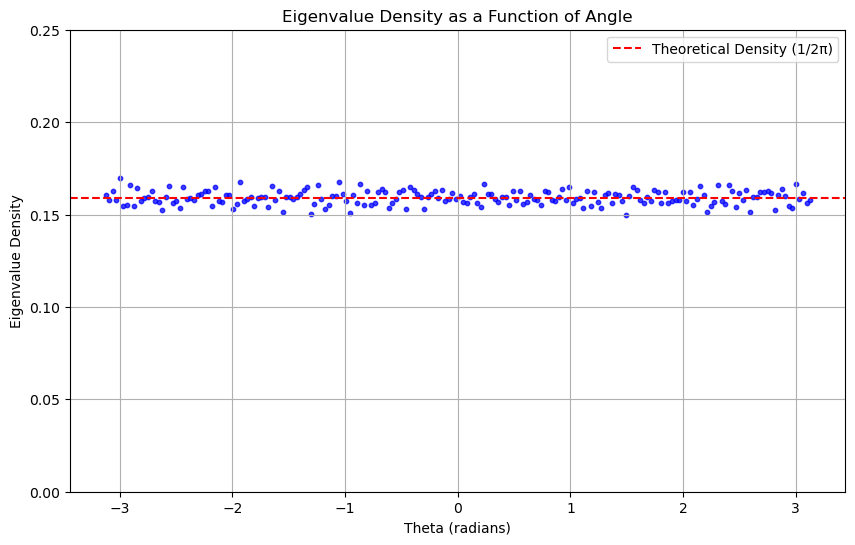

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit.quantum_info import DensityMatrix, random_unitary

# Define the function haar_random_matrix
def haar_random_matrix(n):
    # generates n*n haar random matrix
    z = (np.random.randn(n, n) + 1j * np.random.randn(n, n)) / np.sqrt(2.0)
    q, r = np.linalg.qr(z)
    d = np.diag(r)
    ph = d / np.absolute(d)
    return np.matrix(q @ np.diag(ph) @ q)

# Parameters
n = 50  # Size of the Haar random matrix
num_matrices = 5000  # Increased number of matrices to generate

# Initialize a list to store eigenvalues
eigenvalues = []

# Generate the matrices and compute their eigenvalues
for _ in range(num_matrices):
    matrix = haar_random_matrix(n)
    eigvals = np.linalg.eigvals(matrix)
    eigenvalues.extend(eigvals)

# Convert eigenvalues to a numpy array for easy plotting
eigenvalues = np.array(eigenvalues)

# Compute the angles (theta) of the eigenvalues
angles = np.angle(eigenvalues)

# Create a histogram of the angles
num_bins = 200  # Increased number of bins for better resolution
counts, bin_edges = np.histogram(angles, bins=num_bins, range=(-np.pi, np.pi), density=True)

# Compute the bin centers
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Plot the density as a scatter plot with enlarged y-axis range
plt.figure(figsize=(10, 6))
plt.scatter(bin_centers, counts, s=10, color='blue', alpha=0.75)
plt.axhline(y=1/(2*np.pi), color='r', linestyle='--', label='Theoretical Density (1/2π)')
plt.ylim(0, 0.25)  # Set the y-axis limit to enlarge the view around 0.16
plt.title('Eigenvalue Density as a Function of Angle')
plt.xlabel('Theta (radians)')
plt.ylabel('Eigenvalue Density')
plt.legend()
plt.grid(True)
plt.show()

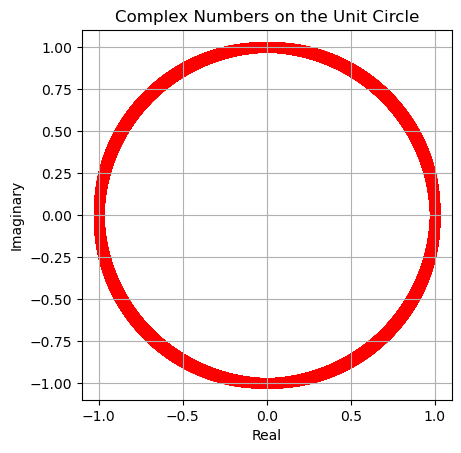

In [2]:
# Calculate the complex numbers e^(i*theta)
complex_numbers = np.exp(1j * np.array(angles))

# Plot the unit circle
unit_circle = plt.Circle((0, 0), 1, color='blue', fill=False)

fig, ax = plt.subplots()
ax.add_artist(unit_circle)

# Plot the complex numbers
plt.scatter(np.real(complex_numbers), np.imag(complex_numbers), color='red',alpha=0.3,marker='x')

# Set equal scaling and grid
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True)

# Add labels and title
plt.xlabel('Real')
plt.ylabel('Imaginary')
plt.title('Complex Numbers on the Unit Circle')

# Show the plot
plt.show()

# Level Spacing Distribution of a Circular Unitary Ensemble (CUE)

The level spacing distribution of a Circular Unitary Ensemble (CUE) describes the probability density of spacings between adjacent eigenvalues of unitary matrices. According to the Wigner surmise for unitary matrices, the spacing distribution \( p(s) \) is given by:

$$
p(s) = \frac{32s^2}{\pi^2} e^{-\frac{4s^2}{\pi}}
$$

where:
- \( s \) is the normalized spacing between consecutive eigenvalues.

This distribution is characterized by a peak near \( s = 1 \) and a tail that decays for larger values of \( s \), indicating that eigenvalues tend to repel each other and avoid being too close or too far apart.

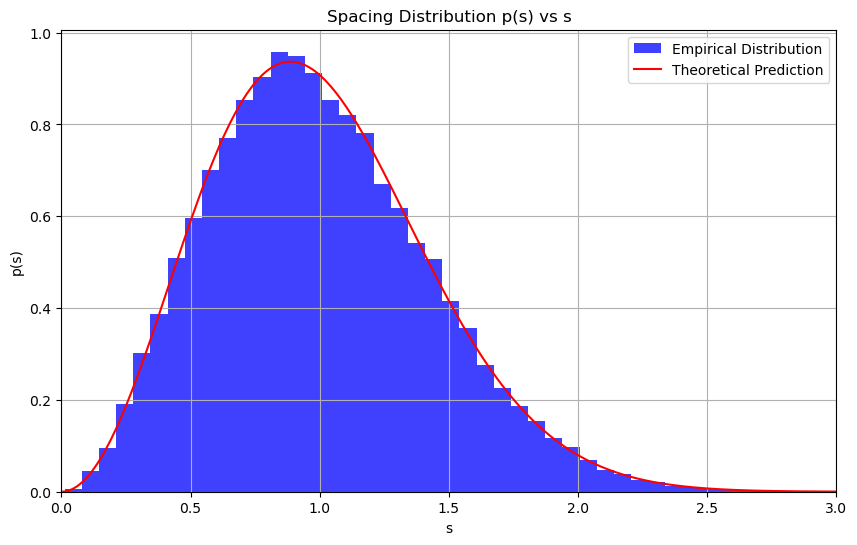

In [4]:
# Parameters
n = 50  # Size of the Haar random matrix
num_matrices = 1000  # Number of matrices to generate

# Initialize a list to store eigenvalue spacings
all_spacings = []

# Generate the matrices and compute their eigenvalue spacings
for _ in range(num_matrices):
    matrix = random_unitary(n).data
    eigvals = np.linalg.eigvals(matrix)
    angles = np.sort(np.angle(eigvals))
    # Compute the spacings
    spacings = np.diff(np.append(angles, angles[0] + 2 * np.pi))
    spacings = (n / (2 * np.pi)) * spacings  # Normalize spacings
    all_spacings.extend(spacings)

# Plot the spacing distribution p(s)
plt.figure(figsize=(10, 6))
plt.hist(all_spacings, bins=50, density=True, alpha=0.75, color='blue', label='Empirical Distribution')

# Theoretical prediction for the CUE level spacing distribution
s_values = np.linspace(0, 3, 300)
p_s = (32 / np.pi**2) * (s_values**2) * np.exp(-4 * s_values**2 / np.pi)
plt.plot(s_values, p_s, 'r-', label='Theoretical Prediction')

plt.title('Spacing Distribution p(s) vs s')
plt.xlabel('s')
plt.ylabel('p(s)')
plt.legend()
plt.grid(True)
plt.xlim(0, 3)  # Focus on the range [0, 3]
plt.show()